In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make charts look nice
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# Load the CSV file
df = pd.read_csv('sales_data.csv')

# Show first 5 rows
df.head()

,Order_ID,Order_Date,State,Gender,Age,Product_Category,Quantity,Unit_Price,Customer_Satisfaction,Total_Price
0,1,2023-04-13,Florida,Male,44,Toys,4,475.59,3,1902.37
1,2,2023-12-15,Texas,Female,39,Toys,4,427.55,5,1710.19
2,3,2023-09-28,Florida,Male,49,Furniture,5,232.52,2,1162.61
3,4,2023-04-17,California,Female,66,Toys,8,436.74,3,3493.94
4,5,2023-03-13,Florida,Male,44,Books,7,118.21,4,827.46


In [3]:
# How many rows and columns?
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Check data types
print("\nData types:")
print(df.dtypes)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())


Rows: 5000, Columns: 10

Data types:
Order_ID                   int64
Order_Date                object
State                     object
Gender                    object
Age                        int64
Product_Category          object
Quantity                   int64
Unit_Price               float64
Customer_Satisfaction      int64
Total_Price              float64
dtype: object

Missing values:
Order_ID                 0
Order_Date               0
State                    0
Gender                   0
Age                      0
Product_Category         0
Quantity                 0
Unit_Price               0
Customer_Satisfaction    0
Total_Price              0
dtype: int64


In [4]:
df.describe()

,Order_ID,Age,Quantity,Unit_Price,Customer_Satisfaction,Total_Price
count,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,43.5114,4.989000,256.460276,2.990800,1272.754680
std,1443.520003,15.0810,2.553857,141.443502,1.418139,1017.660129
min,1.000000,18.0000,1.000000,10.100000,1.000000,13.630000
25%,1250.750000,31.0000,3.000000,135.300000,2.000000,433.590000
50%,2500.500000,43.0000,5.000000,255.715000,3.000000,986.665000
75%,3750.250000,57.0000,7.000000,379.200000,4.000000,1908.910000
max,5000.000000,69.0000,9.000000,499.950000,5.000000,4495.160000


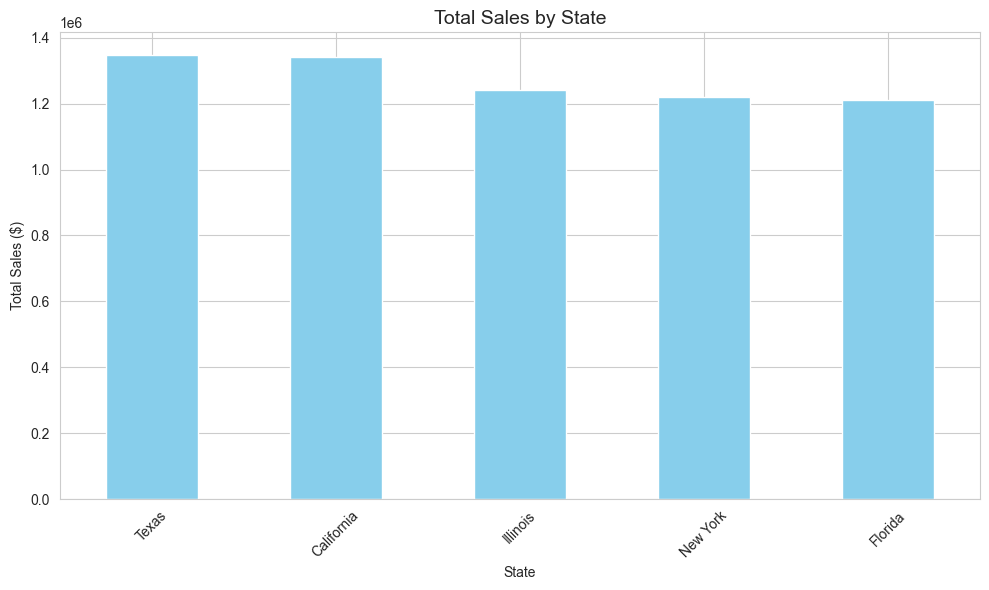

In [5]:
# Total sales by state
sales_by_state = df.groupby('State')['Total_Price'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sales_by_state.plot(kind='bar', color='skyblue')
plt.title('Total Sales by State', fontsize=14)
plt.xlabel('State')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_state.png')
plt.show()

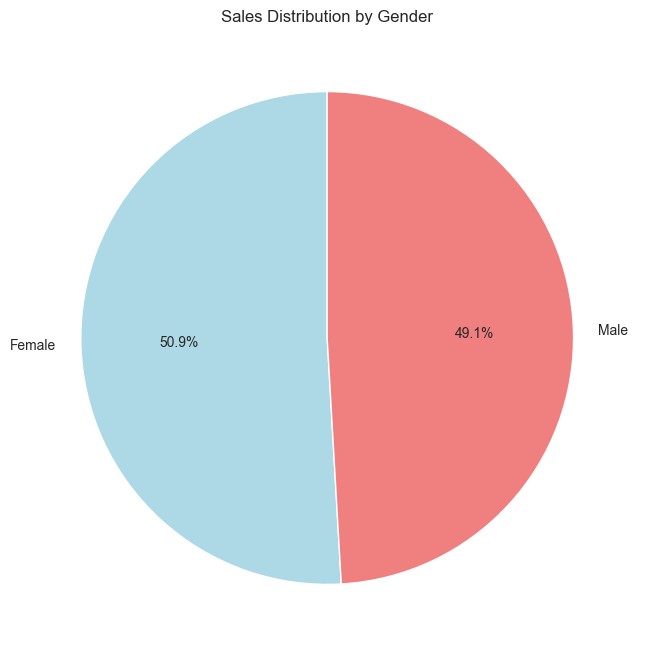

In [6]:
sales_by_gender = df.groupby('Gender')['Total_Price'].sum()

plt.figure(figsize=(8, 8))
plt.pie(sales_by_gender, labels=sales_by_gender.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Sales Distribution by Gender')
plt.savefig('sales_by_gender.png')
plt.show()

C:\Users\Meena\AppData\Local\Temp\ipykernel_7352\1793563399.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales_by_age = df.groupby('Age_Group')['Total_Price'].sum()


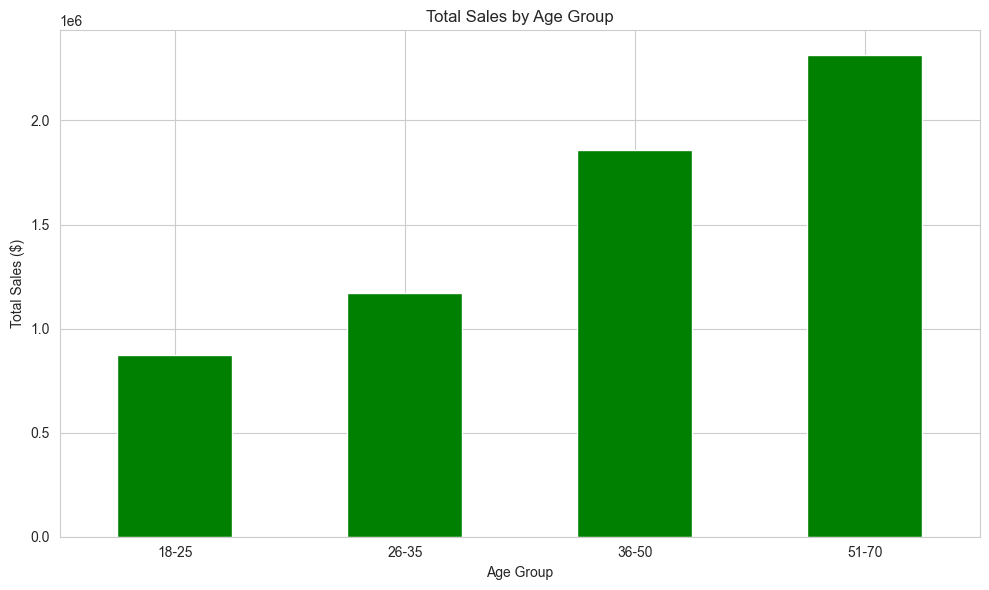

In [7]:
# Create age groups
bins = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

sales_by_age = df.groupby('Age_Group')['Total_Price'].sum()

plt.figure(figsize=(10, 6))
sales_by_age.plot(kind='bar', color='green')
plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sales_by_age.png')
plt.show()

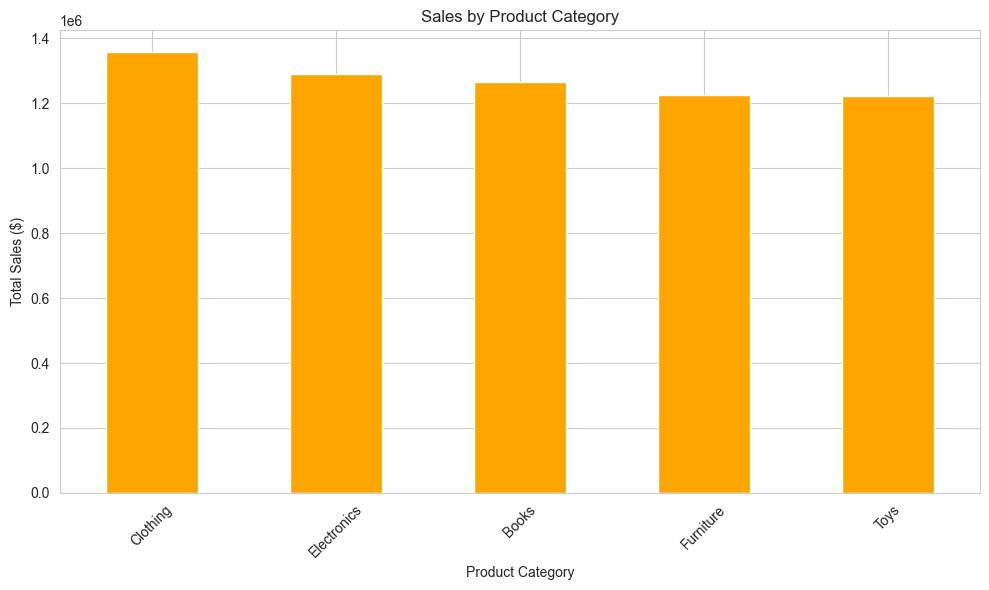

In [8]:
sales_by_category = df.groupby('Product_Category')['Total_Price'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sales_by_category.plot(kind='bar', color='orange')
plt.title('Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_by_category.png')
plt.show()

C:\Users\Meena\AppData\Local\Temp\ipykernel_7352\4002847478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Customer_Satisfaction', palette='viridis')


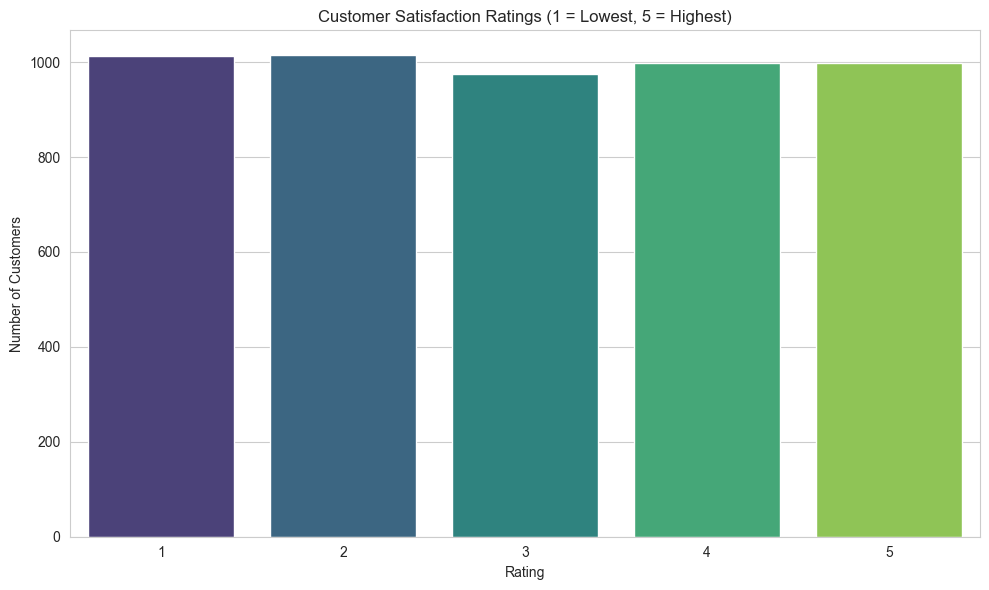

In [9]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Customer_Satisfaction', palette='viridis')
plt.title('Customer Satisfaction Ratings (1 = Lowest, 5 = Highest)')
plt.xlabel('Rating')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('satisfaction_distribution.png')
plt.show()

In [10]:
print("=" * 50)
print("📊 KEY INSIGHTS FROM SALES DATA")
print("=" * 50)

print(f"\n1. Total Revenue: ${df['Total_Price'].sum():,.2f}")
print(f"2. Average Order Value: ${df['Total_Price'].mean():,.2f}")
print(f"3. Best Selling State: {sales_by_state.index[0]} (${sales_by_state.iloc[0]:,.2f})")
print(f"4. Top Product Category: {sales_by_category.index[0]} (${sales_by_category.iloc[0]:,.2f})")
print(f"5. Average Customer Satisfaction: {df['Customer_Satisfaction'].mean():.2f} / 5")
print(f"6. Gender Split: {df['Gender'].value_counts(normalize=True).to_dict()}")

📊 KEY INSIGHTS FROM SALES DATA

1. Total Revenue: $6,363,773.40
2. Average Order Value: $1,272.75
3. Best Selling State: Texas ($1,349,137.53)
4. Top Product Category: Clothing ($1,356,920.70)
5. Average Customer Satisfaction: 2.99 / 5
6. Gender Split: {'Male': 0.5002, 'Female': 0.4998}
